# Hall of Fame Probability — Relief Pitchers
**Logistic Regression Model | Baseball Reference Data**

## Overview

This model estimates the probability that a relief pitcher is inducted into the National Baseball Hall of Fame using logistic regression. Relief pitcher HOF evaluation is the hardest of the three models — the closer role as currently defined did not fully exist before the late 1970s, career WAR for relievers is compressed by inning volume, and the BBWAA has historically undervalued relief pitching.

**Qualification:** Debut after 1975, last season before 2020

**Features used:**
- `sve` — A custom single-feature metric combining saves and ERA+

**Why a single feature?** Relief pitcher performance is fundamentally about two things: how often you were trusted with the highest leverage situations (saves as a proxy), and how well you performed when you got there (ERA+ as the quality measure). A model with one well-constructed feature is more interpretable and less prone to overfitting on a dataset this size than a model with many correlated features. Simplicity is a strength here, not a limitation.

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np

# Load your data
df = pd.read_csv('reliefpitchers.csv')
df = df[df['fromyear'] < 2020]
df = df[df['toyear'] > 1975]
df['sve'] = df['sv'] + df['era_plus']
pos = df


# Define your features and outcome
X = pos[['sve']]
y = pos['hof']

# Split into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

custom_weights = {0: .5, 1: 1}
# Fit the model
model = LogisticRegression(class_weight=custom_weights)
model.fit(X_train, y_train)

# See how well it predicts
print(classification_report(y_test, model.predict(X_test)))

# See the coefficients (which variables matter most)
for feat, coef in zip(X.columns, model.coef_[0]):
    print(f"{feat}: {coef:.10f}")

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00         1

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

sve: 0.0170341440


## Feature Engineering

`sve` (Saves + ERA+) is defined as:

```
sve = SV + ERA+
```

A reliever with 400 career saves and a 130 ERA+ scores 530.  
A reliever with 200 career saves and a 160 ERA+ scores 360.

This deliberately rewards both paths to HOF consideration for relievers:
- The high-volume closer who accumulates saves over a long dominant career (Rivera, Hoffman)
- The dominant shorter-career reliever whose ERA+ is elite even if save totals are lower (Wagner, Smith)

**Acknowledged limitation:** Saves are an opportunity-based statistic. A closer on a great team in a pennant race accumulates more save opportunities than an equally talented closer on a losing team. SVE partially mitigates this through ERA+, but a closer on a perennial contender will still score higher than a comparable closer on a rebuilding team.

In [2]:
from sklearn.model_selection import cross_val_score

auc_scores = cross_val_score(model, X, y, cv=5, scoring='roc_auc')
print(f"Cross-validated AUC: {auc_scores.mean():.3f} (+/- {auc_scores.std():.3f}")

Cross-validated AUC: 0.991 (+/- 0.018


## Model

Logistic regression with custom class weights {0: 0.5, 1: 1.0}. This reduces the penalty for misclassifying non-HOF relievers relative to HOF relievers, reflecting the asymmetry in consequences — missing a true HOF-caliber reliever is a more significant error than flagging a borderline non-inductee.

A precision-recall curve is used to identify the optimal threshold. Cross-validated AUC is the primary performance metric.

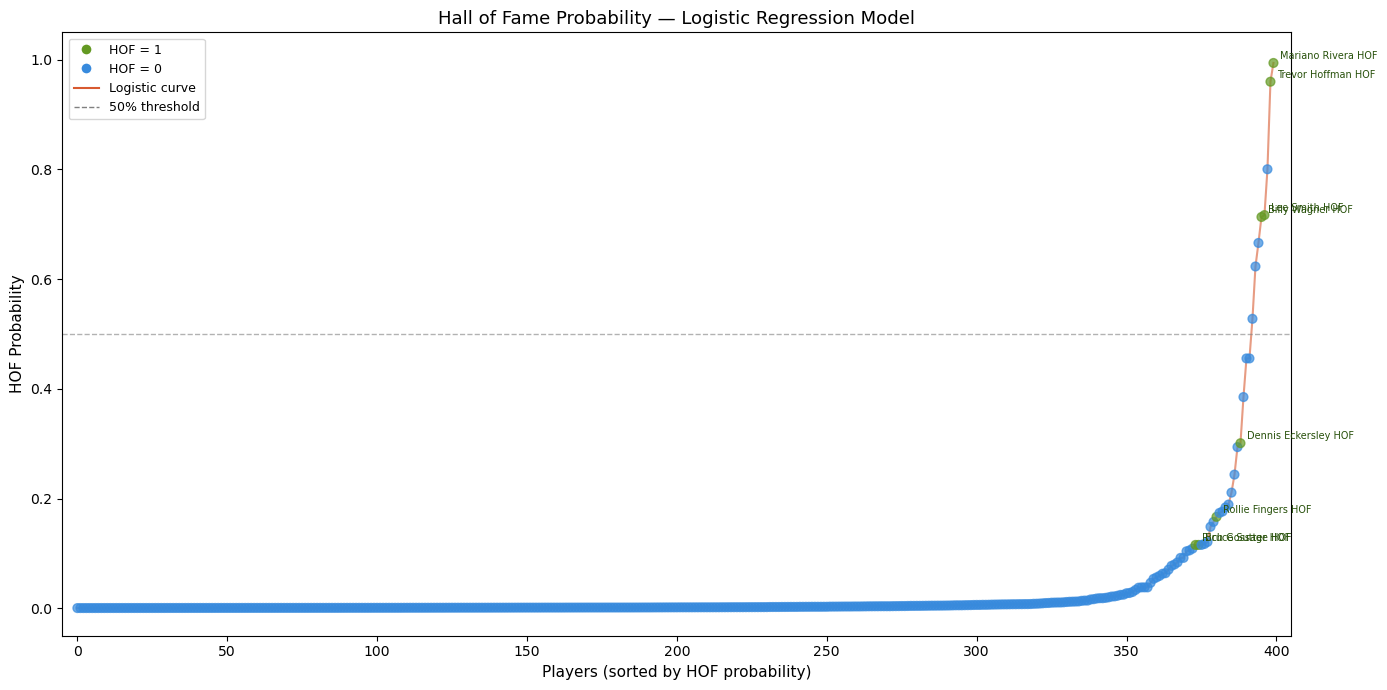

Saved.
                 Player HOF Probability Inducted  FromYear
1    Mariano Rivera HOF           99.4%      Yes      1995
2    Trevor Hoffman HOF           96.0%      Yes      1993
3         Kenley Jansen           80.0%       No      2010
5      Billy Wagner HOF           71.3%      Yes      1995
6         Craig Kimbrel           66.6%       No      2010
7   Francisco Rodríguez           62.3%       No      2002
9       Aroldis Chapman           45.6%       No      2010
10    Jonathan Papelbon           45.6%       No      2005
11           Joe Nathan           38.5%       No      1999
13        Troy Percival           29.4%       No      1995
18        Huston Street           17.6%       No      2005
19    Francisco Cordero           17.4%       No      1999
21    Roberto Hernández           15.7%       No      1991
22             Robb Nen           14.9%       No      1993
24      Fernando Rodney           11.7%       No      2002
29           Todd Jones           10.6%       No 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get predicted HOF probability for every player in df
df['hof_prob'] = model.predict_proba(X)[:, 1]

# Sort by probability for a cleaner plot
df_sorted = df.sort_values('hof_prob').reset_index(drop=True)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))

# Color dots by actual HOF status
colors = df_sorted['hof'].map({0: '#378ADD', 1: '#639922'})
ax.scatter(range(len(df_sorted)), df_sorted['hof_prob'], 
           c=colors, alpha=0.7, zorder=3, s=40)

# Logistic curve overlay — sorted probabilities IS the logistic line
ax.plot(range(len(df_sorted)), df_sorted['hof_prob'], 
        color='#D85A30', linewidth=1.5, alpha=0.6, zorder=2)

# 50% threshold line
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6)

# Label every actual HOFer by name
for idx, row in df_sorted.iterrows():
    if row['hof'] == 1:
        ax.annotate(row['name'], 
                    xy=(idx, row['hof_prob']),
                    xytext=(5, 3), textcoords='offset points',
                    fontsize=7, color='#27500A')

# Formatting
ax.set_xlabel('Players (sorted by HOF probability)', fontsize=11)
ax.set_ylabel('HOF Probability', fontsize=11)
ax.set_title('Hall of Fame Probability — Logistic Regression Model', fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-5, len(df_sorted) + 5)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#639922', markersize=8, label='HOF = 1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#378ADD', markersize=8, label='HOF = 0'),
    Line2D([0], [0], color='#D85A30', linewidth=1.5, label='Logistic curve'),
    Line2D([0], [0], color='gray', linestyle='--', linewidth=1, label='50% threshold')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('rp_probability_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

df_table = df[['name', 'hof_prob', 'hof','fromyear']].copy()

# Sort numerically FIRST while it's still a float
df_table = df_table.sort_values('hof_prob', ascending=False).reset_index(drop=True)
df_table.index += 1
df_table['fromyear'] = (df_table['fromyear']).astype(int)
df_table = df_table[df_table['fromyear'] >= 1990]
# THEN convert to string with % sign
df_table['hof_prob'] = (df_table['hof_prob'] * 100).round(1).astype(str) + '%'
df_table['hof'] = df_table['hof'].map({1: 'Yes', 0: 'No'})
df_table.columns = ['Player', 'HOF Probability', 'Inducted','FromYear']

df_table.to_csv('rp_probabilities.csv')
print(df_table.head(20))

In [4]:
print(f"Intercept: {model.intercept_[0]:.10f}")
print(f"SVE coef: {model.coef_[0][0]:.10f}")

Intercept: -9.4620082304
SVE coef: 0.0170341440


## Results and Interpretation

Because SVE is a single feature, the model is essentially learning a cutoff — above what SVE threshold does HOF induction become likely. The SVE coefficient tells you how much each additional point increases log-odds of induction.

The most interesting predictions are active or recently retired closers who have not yet appeared on the ballot. A reliever crossing the model's probability threshold has a statistical case comparable to inducted relievers — whether the BBWAA agrees is a separate question the model deliberately does not try to predict.

The 1975 debut cutoff means this model is not appropriate for evaluating pre-closer-era relievers whose value came from high-inning middle relief rather than the modern save-accumulation role.

Best threshold for max precision: 0.994
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        39
           1       1.00      1.00      1.00         1

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



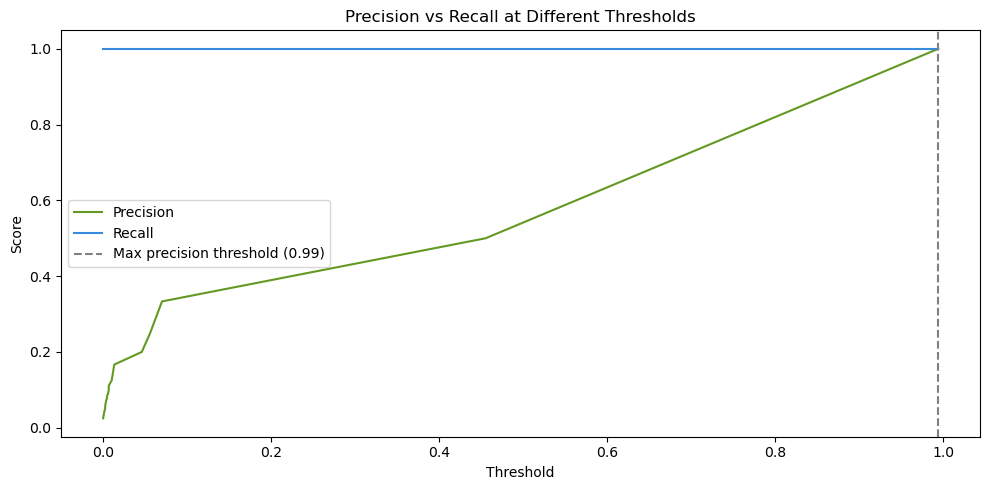

In [5]:
from sklearn.metrics import precision_recall_curve

y_prob = model.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Find threshold that gives maximum precision while still catching at least 1 HOFer
best_threshold = thresholds[precision[:-1].argmax()]
print(f"Best threshold for max precision: {best_threshold:.3f}")

# See what the classification report looks like at that threshold
y_pred_strict = (y_prob >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_strict))
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='#639922')
plt.plot(thresholds, recall[:-1], label='Recall', color='#378ADD')
plt.axvline(best_threshold, color='gray', linestyle='--', label=f'Max precision threshold ({best_threshold:.2f})')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision vs Recall at Different Thresholds')
plt.legend()
plt.tight_layout()
plt.show()